## 1. Project Context

### Data Understanding

### **Context**:

* This notebook represents the first stage of the E-Commerce Business Analytics project.

* Before performing data cleaning, transformation, or analysis, it is necessary to understand the structure and quality of the available datasets.

The raw data is distributed across four main datasets:

- Customers
- Orders
- Payments
- Products

## 2. Objectives

The objectives of this notebook are to:

- Understand the structure of each dataset.
- Identify the available variables and their data types.
- Explore the main characteristics of the data.
- Identify missing and duplicate values.
- Detect potential data quality issues.
- Investigate relationships between datasets.
- Identify possible keys and relationships for future relational data modeling.

## 3. Import Libraries

In [33]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 4. Load the Raw Data

In [9]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_PATH / "raw"

# Data Set Loading:
customers = pd.read_csv(RAW_DATA_PATH / "customers.csv")
orders = pd.read_csv(RAW_DATA_PATH / "orders.csv")
payments = pd.read_csv(RAW_DATA_PATH / "payments.csv")
products = pd.read_csv(RAW_DATA_PATH / "products.csv")

# Verification:

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Payments": payments,
    "Products": products,
}

for name, dataframe in datasets.items():
    print(f"{name}: {dataframe.shape}")

Customers: (10000, 5)
Orders: (50120, 8)
Payments: (50000, 4)
Products: (20, 4)


## 5. Dataset Overview

In this section, I will provide an initial overview of the datasets used in the project.

My goal is to understand the size and structure of each dataset before performing a more detailed data analysis.

-----

### Dataset Dimensions

In [ ]:
dataset_overview = pd.DataFrame(
    {
        "Dataset": list(datasets.keys()),
        "Rows": [df.shape[0] for df in datasets.values()],
        "Columns": [df.shape[1] for df in datasets.values()],
    }
)

dataset_overview

,Dataset,Rows,Columns
0,Customers,10000,5
1,Orders,50120,8
2,Payments,50000,4
3,Products,20,4


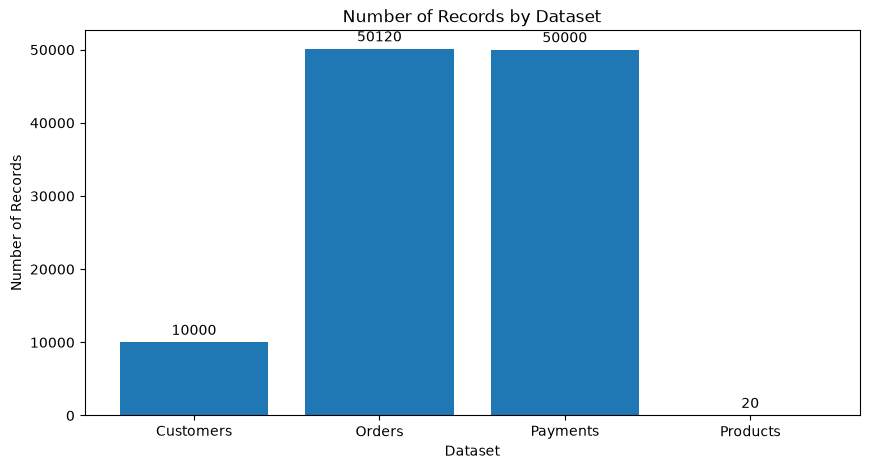

In [ ]:
# Dataset size comparison
plt.figure(figsize=(10, 5))

bars = plt.bar(
    dataset_overview["Dataset"],
    dataset_overview["Rows"],
)

plt.title("Number of Records by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")

plt.bar_label(bars, padding=3)

plt.show()

#### Initial Observations

The dataset contains four main tables:

- Customers: 10,000 records and 5 columns.
- Orders: 50,120 records and 8 columns.
- Payments: 50,000 records and 4 columns.
- Products: 20 records and 4 columns.

* The `Orders` dataset contains the largest number of records, while the `Products` dataset represents a relatively small product catalog.

* The difference between the number of records in the `Orders` and `Payments` datasets will **require further investigation** during the relationship analysis stage.

-----

### Data Preview

Before evaluating data quality, it is important to inspect sample records from each dataset to better understand the available variables and the type of information represented by each record.

The following preview displays the first five records from each dataset.

In [11]:
for name, dataframe in datasets.items():
    print(f"\n{name.upper()}")
    display(dataframe.head())


CUSTOMERS


,CustomerID,Age,City,SignupDate,CustomerSegment
0,100001,22.0,Tehran,2023-09-11,Regular
1,100002,55.0,Tabriz,2024-01-16,VIP
2,100003,49.0,Karaj,2025-07-31,New
3,100004,39.0,Tehran,2023-04-23,New
4,100005,38.0,Tehran,2023-04-29,Regular



ORDERS


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed
3,500004,108780,2024-10-11,2012,1.0,0.1,Gateway,Completed
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed



PAYMENTS


,PaymentID,OrderID,PaymentDate,PaymentStatus
0,800001,500001,2025-08-28,Paid
1,800002,500002,2024-05-31,Paid
2,800003,500003,2025-08-10,Paid
3,800004,500004,2024-10-11,Paid
4,800005,500005,2024-02-19,Paid



PRODUCTS


,ProductID,ProductName,Category,UnitPrice
0,2001,Wireless Mouse,Electronics,18.0
1,2002,Mechanical Keyboard,Electronics,62.0
2,2003,USB-C Cable,Accessories,9.0
3,2004,Power Bank,Electronics,35.0
4,2005,Laptop Stand,Accessories,28.0


#### Initial Observations

* The preview showed that the datasets contain different types of information related to the e-commerce operation:

- The `Customers` dataset contains demographic and segmentation information about customers.
- The `Orders` dataset contains transactional information, including the customer associated with each order, the purchased product, quantity, discount, payment method, and order status.
- The `Payments` dataset contains information related to payments associated with orders.
- The `Products` dataset contains information about the available products and their respective categories and prices.

* The presence of common identifiers such as `CustomerID`, `OrderID`, and `ProductID` suggests me that potential relationships between the datasets. I will investigate these relationships in more detail during the relationship analysis stage.

-----

### Data Types

* The data types of each column provide an initial indication of how the information is currently stored.

* This inspection helps identify potential type inconsistencies that may need to be addressed during the data processing stage.

In [12]:
for name, dataframe in datasets.items():
    print(f"\n{name.upper()}")
    display(dataframe.dtypes.to_frame(name="Data Type"))


CUSTOMERS


,Data Type
CustomerID,int64
Age,float64
City,str
SignupDate,str
CustomerSegment,str



ORDERS


,Data Type
OrderID,int64
CustomerID,int64
OrderDate,str
ProductID,int64
Quantity,float64
Discount,float64
PaymentMethod,str
Status,str



PAYMENTS


,Data Type
PaymentID,int64
OrderID,int64
PaymentDate,str
PaymentStatus,str



PRODUCTS


,Data Type
ProductID,int64
ProductName,str
Category,str
UnitPrice,float64


#### Initial Observations

* Most identifier columns are currently stored as `int64`, while variables such as age, quantity, and discount are stored as `float64`.

* Categorical and date-related variables are currently stored as strings.

* The date columns will require further evaluation to determine whether they should be converted to a datetime format during the data processing stage.

-----

### Dataset Granularity

Before performing data quality checks, it is necessary to understand what a single row represents in each dataset.

This is especially important for identifying potential keys and understanding how the datasets may be related.

#### Customers

In [16]:
customers["CustomerID"].nunique(), len(customers)

(10000, 10000)

In [17]:
customers["CustomerID"].duplicated().sum()

np.int64(0)

* The `CustomerID` column contains **10,000 unique values**, matching the **total number of records** in the dataset. No duplicated customer identifiers were found.
* This provides strong evidence that **each row represents one customer**.

#### Products

In [25]:
products["ProductID"].nunique(), len(products)

(20, 20)

In [19]:
products["ProductID"].duplicated().sum()

np.int64(0)

* The `ProductID` column contains a **unique identifier** for each of the 20 product records. No duplicated product identifiers were found.

* This provides strong evidence that each row represents one product. I am going to confirm that later.

#### Orders

I will determine whether `OrderID` uniquely identifies each record and investigate the repeated order identifiers.

In [20]:
orders["OrderID"].nunique(), len(orders)

(50000, 50120)

In [21]:
orders["OrderID"].duplicated().sum()

np.int64(120)

* The `Orders` dataset contains 50,000 unique order identifiers across 50,120 records. Therefore, the `OrderID` column is not unique, with 120 records containing an identifier that appears more than once.

-----

#### Investigating Repeated Order Identifiers

* Since the number of records in the `Orders` dataset *exceeds* the number of unique `OrderID` values, the repeated identifiers require further investigation.

* The purpose of this analysis is to examine the records associated with repeated order identifiers and identify which variables differ between them.

In [36]:
duplicated_order_ids = orders[
    orders["OrderID"].duplicated(keep=False)
].sort_values("OrderID")

duplicated_order_ids.head(10)

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
199,500200,104768,2025-08-03,2008,2.0,0.1,CardToCard,Completed
50002,500200,104768,2025-08-03,2008,2.0,0.1,CardToCard,Completed
725,500726,102977,2025-11-26,2013,2.0,0.1,Wallet,Returned
50061,500726,102977,2025-11-26,2013,2.0,0.1,Wallet,Returned
821,500822,100897,2026-01-03,2003,1.0,0.0,Gateway,Completed
50022,500822,100897,2026-01-03,2003,1.0,0.0,Gateway,Completed
1414,501415,108793,2025-02-28,2004,1.0,0.1,Wallet,Completed
50013,501415,108793,2025-02-28,2004,1.0,0.1,Wallet,Completed
50092,501813,108688,2025-12-20,2014,2.0,0.1,NaN,Completed
1812,501813,108688,2025-12-20,2014,2.0,0.1,NaN,Completed


#### Initial Observation

* The **repeated records** that I have examined during this investigation **contain identical values** across all available variables.

* For example, the records associated with `OrderID` `500726` have the same **customer**, **order date**, **product**, **quantity**, **discount**, **payment method**, and **status** of the payment.

* This suggests that at least some repeated `OrderID` values may represent duplicated records rather than multiple items associated with the same order.

* A more comprehensive duplicate analysis will be performed during the **Data Quality Assessment stage**.

-----

#### Complete Duplicate Records

The initial inspection suggests that some repeated `OrderID` values may be associated with **completely identical records**.

A preliminary check can help determine whether the difference between the total number of records and unique order identifiers is caused by complete duplicate records.

In [37]:
orders.duplicated().sum()

np.int64(120)

* This means that `Orders` dataset contains **120 completely duplicated records**. This result matches the difference between the total number of records **(50,120)** and the number of unique `OrderID` values **(50,000)**.

* Therefore, the repeated `OrderID` values identified during the initial investigation **appear to be caused by completely duplicated records** rather than multiple products associated with the same order.

* I will **further evaluate** these duplicate records during the **Data Quality Assessment stage** before any data cleaning decisions are made.

#### Payments

Now I will determine whether `PaymentID` and `OrderID` uniquely identify payment records.

In [31]:
payment_identifier_analysis = pd.DataFrame(
    {
        "Identifier": ["PaymentID", "OrderID"],
        "Unique Values": [
            payments["PaymentID"].nunique(),
            payments["OrderID"].nunique(),
        ],
        "Total Records": [
            len(payments),
            len(payments),
        ],
        "Duplicated Records": [
            payments["PaymentID"].duplicated().sum(),
            payments["OrderID"].duplicated().sum(),
        ],
    }
)

payment_identifier_analysis

,Identifier,Unique Values,Total Records,Duplicated Records
0,PaymentID,50000,50000,0
1,OrderID,50000,50000,0


* Both `PaymentID` and `OrderID` contain **50,000 unique values**, matching the **total number of records** in the dataset. No duplicated values were found for either identifier.

* This provides strong evidence that **each row represents a single payment record associated with a unique order**.

* However, the relationship between payment records and orders will be further validated during the relationship analysis stage.

-----

#### Granularity Summary

| Dataset | One Record Represents |
|---|---|
| Customers | One customer |
| Orders | One order |
| Payments | One payment record associated with an order |
| Products | One product |

* The initial granularity assessment indicates that **the four datasets represent different business entities** within the e-commerce operation.

* The datasets appear to be connected through identifiers such as `CustomerID`, `OrderID`, and `ProductID`. These relationships will be investigated in more detail during the **relationship analysis stage**.

## 6. Data Quality Assessment

* Before performing further analysis, it is very important to evaluate the quality and consistency of the datasets.

* This section investigates **potential issues** that may affect the **reliability of the analysis**, including missing values, duplicate records, data type inconsistencies, and potentially invalid values.

* My objective is to identify data quality issues before making any data cleaning or transformation decisions.

----

### Missing Values Analysis

* Missing values can **affect data analysis**, aggregation, and future data transformations.

* In the following analysis I will examine the number and percentage of missing values in each column across all datasets.

In [38]:
missing_values = pd.DataFrame(
    {
        "Missing Values": [
            dataframe.isna().sum().sum()
            for dataframe in datasets.values()
        ],
        "Total Values": [
            dataframe.size
            for dataframe in datasets.values()
        ],
    },
    index=datasets.keys(),
)

missing_values["Missing Percentage"] = (
    missing_values["Missing Values"]
    / missing_values["Total Values"]
    * 100
)

missing_values

,Missing Values,Total Values,Missing Percentage
Customers,299,50000,0.598000
Orders,788,400960,0.196528
Payments,35,200000,0.017500
Products,0,80,0.000000


#### Initial Observations

I have identified missing values in the `Customers`, `Orders`, and `Payments` datasets in my initial analysis.

- `Customers` contains **299** missing values.
- `Orders` contains **788** missing values.
- `Payments` contains **35** missing values.
- `Products` contains **no** missing values.

* Although the overall percentage of missing values is relatively low when considering all values within each dataset, this aggregated view does not indicate which specific columns contain the missing information.

* Therefore, a **column-level analysis is necessary** to identify where the missing values are concentrated and evaluate their **potential impact on the analysis**.

-----

#### Column-Level Missing Values Analysis

The following analysis examines missing values at the column level to identify where missing information is concentrated within each dataset.

In [39]:
for name, dataframe in datasets.items():
    missing_by_column = dataframe.isna().sum()
    missing_by_column = missing_by_column[
        missing_by_column > 0
    ]

    print(f"\n{name.upper()}")

    if not missing_by_column.empty:
        display(
            missing_by_column.to_frame(
                name="Missing Values"
            )
        )
    else:
        print("No missing values found.")


CUSTOMERS


,Missing Values
Age,180
City,119



ORDERS


,Missing Values
OrderDate,35
Quantity,80
Discount,221
PaymentMethod,452



PAYMENTS


,Missing Values
PaymentDate,35



PRODUCTS
No missing values found.


#### Initial Observations

The column-level analysis shows that missing values are concentrated in a limited number of variables across three datasets.

- In `Customers`, missing values were identified in `Age` (180 records) and `City` (119 records).
- In `Orders`, missing values were identified in `OrderDate` (35 records), `Quantity` (80 records), `Discount` (221 records), and `PaymentMethod` (452 records).
- In `Payments`, 35 records are missing `PaymentDate`.
- `Products` contains no missing values.

The `PaymentDate` and `OrderDate` columns contain the same number of missing values (35), which may indicate a potential relationship between the missing records in the two datasets. This will be investigated further during the relationship analysis.

The missing values identified in `Orders` and `Payments` may affect calculations involving transaction dates, quantities, discounts, and payment information. Their impact will be evaluated before deciding how they should be handled during the data processing stage.

-----
### Missing Value Percentage

The number of missing values alone does not indicate the magnitude of the problem within each variable.

Therefore, the percentage of missing values is calculated relative to the total number of records in each dataset.

In [40]:
for name, dataframe in datasets.items():
    missing = dataframe.isna().sum()
    
    missing = missing[missing > 0]
    
    if not missing.empty:
        missing_percentage = (
            missing / len(dataframe) * 100
        )
        
        missing_analysis = pd.DataFrame(
            {
                "Missing Values": missing,
                "Missing Percentage": missing_percentage,
            }
        )
        
        print(f"\n{name.upper()}")
        display(missing_analysis)


CUSTOMERS


,Missing Values,Missing Percentage
Age,180,1.80
City,119,1.19



ORDERS


,Missing Values,Missing Percentage
OrderDate,35,0.069832
Quantity,80,0.159617
Discount,221,0.440942
PaymentMethod,452,0.901836



PAYMENTS


,Missing Values,Missing Percentage
PaymentDate,35,0.07


#### Initial Observations

The percentage analysis confirms that missing values represent a **relatively small portion** of each dataset.

- In `Customers`, missing values affect `Age` (1.80%) and `City` (1.19%).
- In `Orders`, `PaymentMethod` has the highest proportion of missing values (0.90%), followed by `Discount` (0.44%), `Quantity` (0.16%), and `OrderDate` (0.07%).
- In `Payments`, 0.07% of the records are missing `PaymentDate`.
- `Products` contains no missing values.

Although the overall proportion of missing values is low, the impact of each variable depends on its role in the analysis. For example, missing values in `OrderDate` may affect time-based analysis, while missing values in `Quantity` and `Discount` may affect revenue calculations.

The missing values will not be automatically removed at this stage. Their treatment will be evaluated during the data processing stage based on their business relevance and relationship with other variables.

----

### Duplicate Records

Duplicate records can lead to inaccurate results by artificially increasing the number of transactions or other aggregated measures.

The first step is to identify complete duplicate rows, where all column values are identical within each dataset.

In [41]:
for name, dataframe in datasets.items():
    duplicate_count = dataframe.duplicated().sum()

    print(f"{name.upper()}: {duplicate_count} duplicate records")

CUSTOMERS: 0 duplicate records
ORDERS: 120 duplicate records
PAYMENTS: 0 duplicate records
PRODUCTS: 0 duplicate records


#### Initial Observations

The duplicate analysis identified complete duplicate records only in the `Orders` dataset.

- `Customers`, `Payments`, and `Products` contain no complete duplicate records.
- `Orders` contains 120 complete duplicate records.
- These 120 records correspond to the difference between the total number of order records (50,120) and the number of unique `OrderID` values (50,000).

The duplicate records appear to represent repeated copies of existing orders rather than distinct transactions. They should therefore be removed during the data processing stage to prevent duplicate orders from affecting future analysis.

-----

### Invalid / Suspicious Values

* Missing values and duplicate records are not the only potential data quality issues.

* Values can also be present but inconsistent with the expected business context. Therefore, numerical variables are examined for potentially invalid or suspicious values before the data processing stage.

### Age

The `Age` variable is examined to identify values outside the expected range.

In [42]:
customers["Age"].describe()

count    9820.000000
mean       41.321487
std        13.802441
min        18.000000
25%        29.000000
50%        41.000000
75%        53.000000
max        65.000000
Name: Age, dtype: float64

In [52]:
invalid_age = customers[
    (customers["Age"] <= 0) |
    (customers["Age"] > 100)
]

invalid_age

,CustomerID,Age,City,SignupDate,CustomerSegment


### Quantity

The `Quantity` variable is examined to identify zero or negative values.

In [ ]:
(orders["Quantity"] <= 0).sum()

np.int64(25)

### Discount

The `Discount` variable is examined to identify values outside the expected range of 0 to 1.

In [57]:
((orders["Discount"] < 0) | (orders["Discount"] > 1)).sum()

np.int64(0)

In [48]:
invalid_discount = orders[
    (orders["Discount"] < 0) |
    (orders["Discount"] > 1)
]

invalid_discount

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status


### Product Price

The `UnitPrice` variable is examined to identify zero or negative product prices.

In [58]:
(products["UnitPrice"] <= 0).sum()

np.int64(0)

#### Initial Observations

The validation of numerical variables did not identify values outside the expected ranges for `Age`, `Quantity`, `Discount`, or product `Price`.

- `Age` values are within the expected range for the analysis.
- `Quantity` contains no zero or negative values.
- `Discount` values remain within the expected range of 0 to 1.
- Product `Price` contains no zero or negative values.

These results indicate that the numerical variables do not present apparent range-related data quality issues. However, this validation does not guarantee that every value is correct, as some inconsistencies may only be identified through relationships between datasets or business rules.

The identified missing values and duplicate records will be addressed during the data processing stage.

-----
### Date Consistency

Date variables are currently stored as strings. Their values are examined to identify invalid or inconsistent dates before converting them to a datetime format during the data processing stage.

#### Customers

The `SignupDate` column is checked for values that cannot be interpreted as valid dates.

In [64]:
pd.to_datetime(
    customers["SignupDate"],
    errors="coerce"
).isna().sum()

np.int64(0)

#### Orders

The `OrderDate` column is checked for values that cannot be interpreted as valid dates.

In [61]:
pd.to_datetime(
    orders["OrderDate"],
    errors="coerce"
).isna().sum()

np.int64(35)

#### Payments

The `PaymentDate` column is checked for values that cannot be interpreted as valid dates.

In [62]:
pd.to_datetime(
    payments["PaymentDate"],
    errors="coerce"
).isna().sum()

np.int64(35)

-----
#### Date Range

The minimum and maximum dates are examined to identify potentially inconsistent date ranges across the datasets.

In [63]:
for name, dataframe, column in [
    ("Customers", customers, "SignupDate"),
    ("Orders", orders, "OrderDate"),
    ("Payments", payments, "PaymentDate"),
]:
    dates = pd.to_datetime(dataframe[column], errors="coerce")

    print(f"{name}:")
    print(f"  Minimum date: {dates.min()}")
    print(f"  Maximum date: {dates.max()}")

Customers:
  Minimum date: 2023-01-01 00:00:00
  Maximum date: 2025-12-30 00:00:00
Orders:
  Minimum date: 2024-01-01 00:00:00
  Maximum date: 2026-06-30 00:00:00
Payments:
  Minimum date: 2024-01-01 00:00:00
  Maximum date: 2026-06-30 00:00:00


#### Initial Observations

- The date validation did not identify apparent invalid dates outside the expected period of the datasets.
- The date columns contain missing values, but no additional date inconsistencies were identified during this initial assessment.
- The `SignupDate`, `OrderDate`, and `PaymentDate` variables are currently stored as strings and will be converted to datetime format during the data processing stage to support time-based analysis.
- Overall, the main data quality issues identified so far are missing values and duplicate records in the `Orders` dataset.

-----
### Data Quality Summary

The data quality assessment identified a small number of issues that should be considered before performing further analysis.

- Missing values were identified in `Customers`, `Orders`, and `Payments`, although their overall proportion is relatively low.
- `Orders` contains 120 complete duplicate records.
- No apparent invalid values were identified in `Age`, `Quantity`, `Discount`, or `UnitPrice`.
- The date variables contain missing values but no additional apparent inconsistencies.
- Date columns are currently stored as strings and will require conversion during the data processing stage.

These findings provide an initial understanding of the main data quality considerations. The identified issues will be addressed systematically during the data cleaning and transformation stage.

------
## 7. Descriptive Analysis

* After assessing the structure and quality of the datasets, the next step is to explore their main characteristics through descriptive statistics.

* This section focuses on understanding the distributions and general behavior of the main variables before investigating relationships between datasets.

### Customer Analysis

The customer dataset contains demographic and segmentation information that can help describe the overall customer base.

#### Age Distribution

The distribution of customer age is examined to understand the demographic profile of the customer base.

In [65]:
customers["Age"].describe()

count    9820.000000
mean       41.321487
std        13.802441
min        18.000000
25%        29.000000
50%        41.000000
75%        53.000000
max        65.000000
Name: Age, dtype: float64

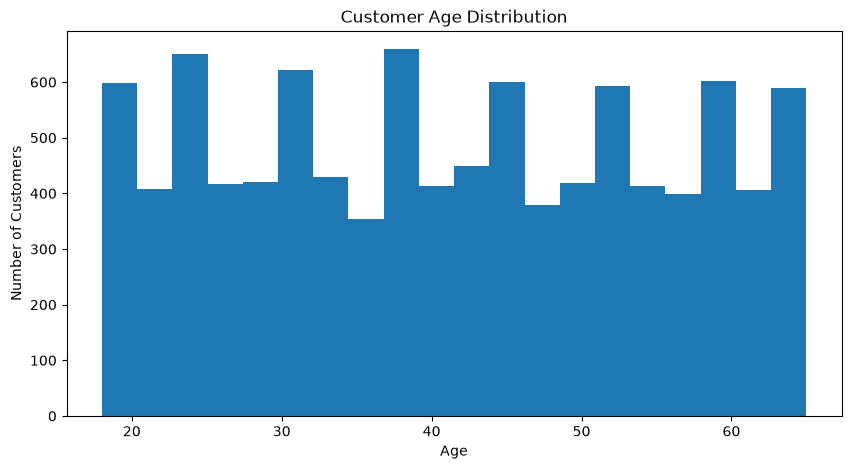

In [66]:
plt.figure(figsize=(10, 5))

plt.hist(
    customers["Age"].dropna(),
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

#### Initial Observations

* The customer age distribution provides an overview of the demographic profile of the customer base.

* The descriptive statistics and histogram should be considered together to identify the most common age ranges and the overall spread of customer ages.

* Missing values in `Age` were identified during the data quality assessment and are excluded from the visualization. Their treatment will be addressed during the data processing stage.

-----
### Customer Segmentation

The distribution of customer segments is examined to understand how the customer base is divided between different customer profiles.

In [67]:
customers["CustomerSegment"].value_counts()

CustomerSegment
Regular    5563
New        3462
VIP         975
Name: count, dtype: int64

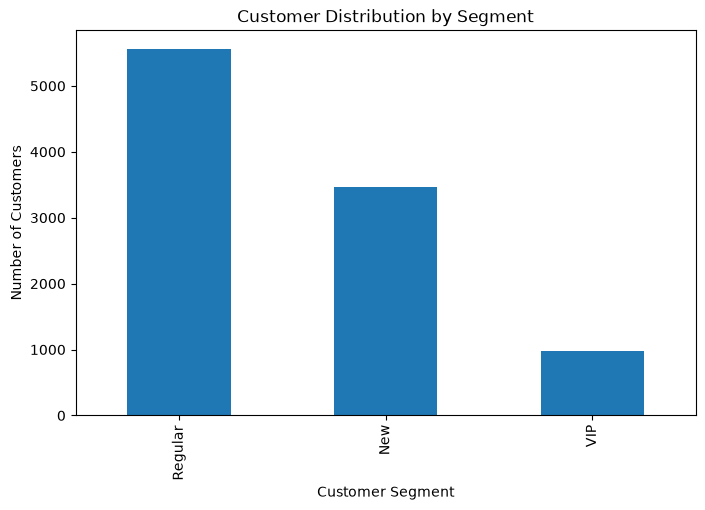

In [68]:
customers["CustomerSegment"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

#### Initial Observations

* The customer segments are not equally distributed across the customer base.

* The distribution indicates differences in the number of customers assigned to each segment, which may be relevant when analyzing purchasing behavior and revenue across customer groups.

-----
### Order Analysis

The orders dataset provides information about customer transactions, including quantity, discounts, payment methods, and order status.

#### Order Quantity

The `Quantity` variable is examined to understand the distribution of items purchased per order.

In [69]:
orders["Quantity"].describe()

count    50040.000000
mean         1.881455
std          1.078846
min         -2.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          5.000000
Name: Quantity, dtype: float64

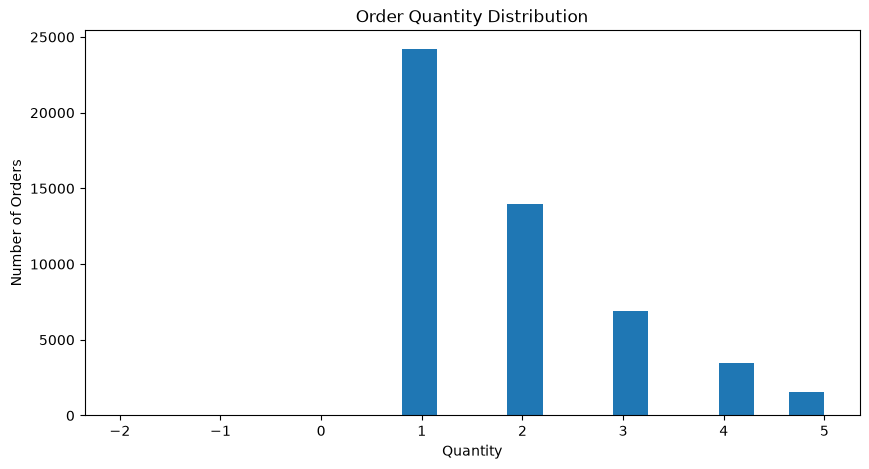

In [70]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders["Quantity"].dropna(),
    bins=20
)

plt.title("Order Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.show()

#### Discount

The `Discount` variable is examined to understand the distribution of discounts applied to orders.

In [71]:
orders["Discount"].describe()

count    49899.000000
mean         0.075130
std          0.077492
min          0.000000
25%          0.000000
50%          0.050000
75%          0.100000
max          0.300000
Name: Discount, dtype: float64

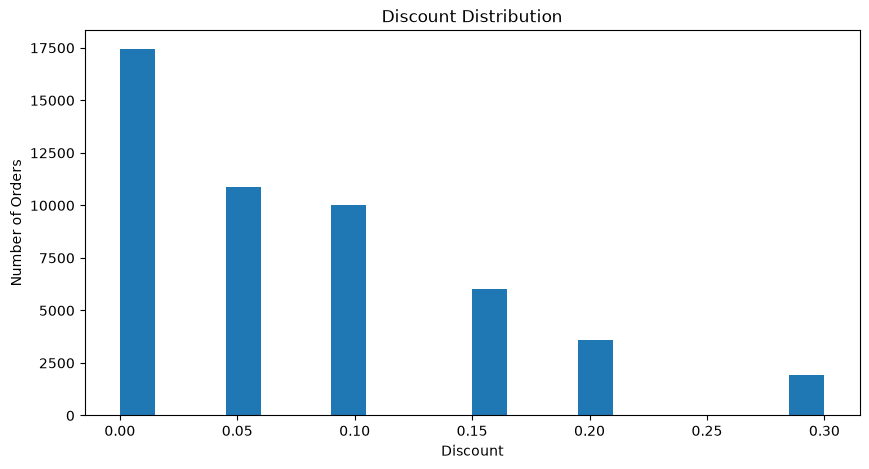

In [72]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders["Discount"].dropna(),
    bins=20
)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Number of Orders")

plt.show()

-----
### Order Status

The distribution of order statuses is examined to understand the overall outcome of customer orders.

In [73]:
orders["Status"].value_counts()

Status
Completed    46105
Cancelled     2477
Returned      1538
Name: count, dtype: int64

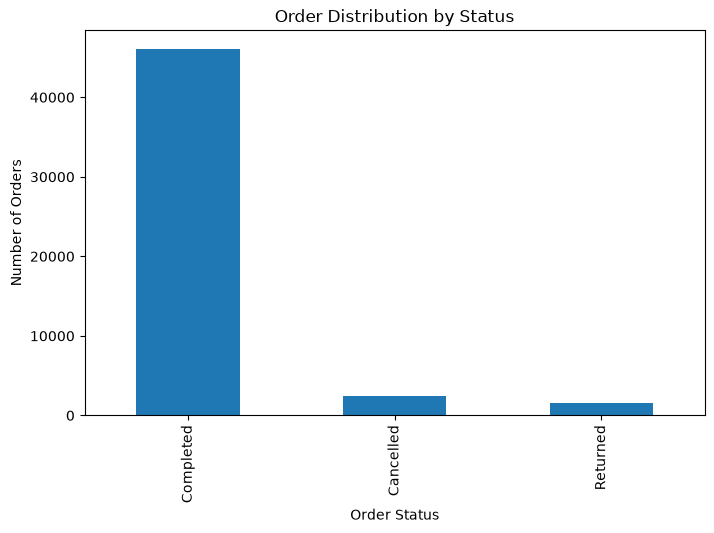

In [74]:
orders["Status"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Order Distribution by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

#### Initial Observations

* The distribution of order statuses provides an overview of the different outcomes observed across transactions.

* The results can be used to understand the relative proportion of completed, returned, cancelled, or other order statuses present in the dataset.

* Order status will also be considered in later analyses when evaluating sales performance and business outcomes.

-----

### Payment Methods

The distribution of payment methods is examined to understand how customers complete their purchases.

In [75]:
orders["PaymentMethod"].value_counts()

PaymentMethod
Gateway       23877
CardToCard    11981
Wallet         8804
Cash           5006
Name: count, dtype: int64

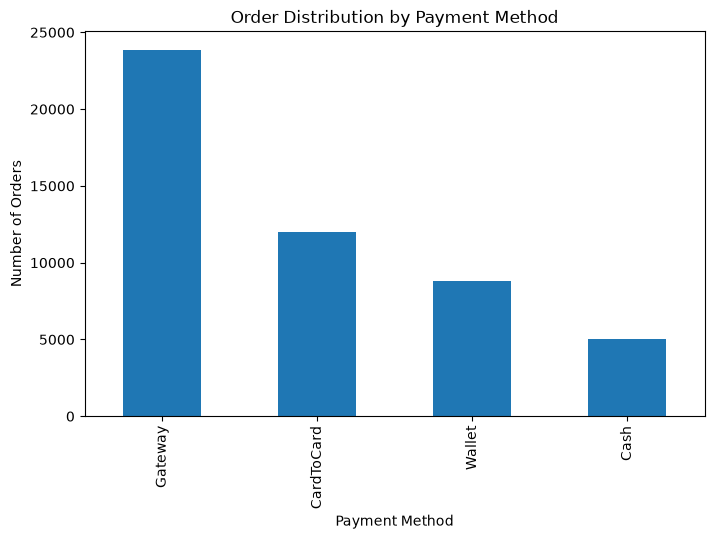

In [77]:
orders["PaymentMethod"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Order Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.show()

#### Initial Observations

* The distribution of payment methods indicates differences in how customers complete their purchases.

* The most frequently used payment methods can provide useful context for later analyses involving transaction volume and customer behavior.

* Missing values in `PaymentMethod` were identified during the data quality assessment and are excluded from this distribution.

-----
### Product Analysis

The products dataset provides information about the products available in the e-commerce operation, including their categories and unit prices.

#### Product Categories

The distribution of products across categories is examined to understand the composition of the product catalog.

In [78]:
products["Category"].value_counts()

Category
Electronics    9
Accessories    5
Wearables      2
Home Office    2
Stationery     1
Gaming         1
Name: count, dtype: int64

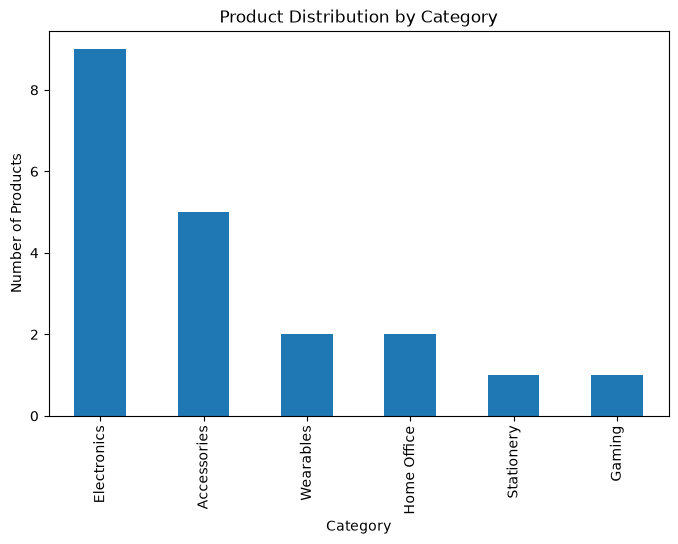

In [79]:
products["Category"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Product Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

#### Initial Observations

The product catalog is distributed across multiple categories, with differences in the number of products available in each category.

This distribution provides context for later analyses of product sales and revenue by category.

#### Unit Price

The `UnitPrice` variable is examined to understand the price range of the products available in the catalog.

In [80]:
products["UnitPrice"].describe()

count     20.000000
mean      61.400000
std       62.836798
min        7.000000
25%       20.250000
50%       45.000000
75%       69.750000
max      260.000000
Name: UnitPrice, dtype: float64

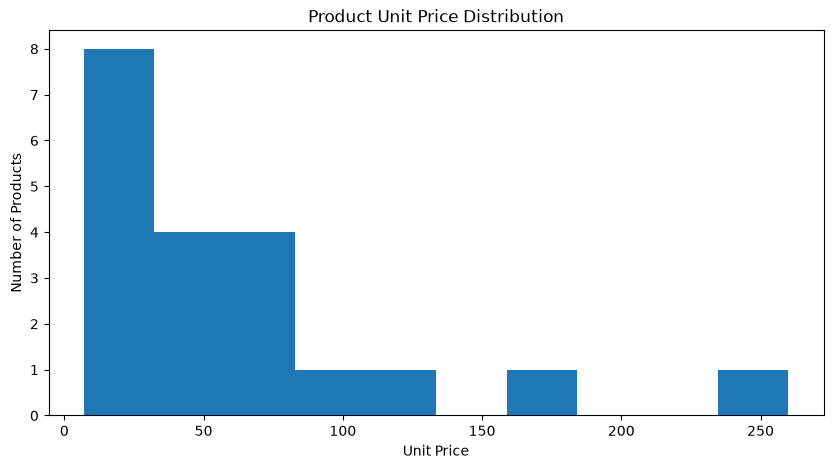

In [81]:
plt.figure(figsize=(10, 5))

plt.hist(
    products["UnitPrice"],
    bins=10
)

plt.title("Product Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Number of Products")

plt.show()

#### Initial Observations

The product prices show variation across the available catalog.

The descriptive statistics and histogram provide an overview of the price range and distribution of product prices, which will be useful when evaluating product performance in later analyses.

-----
### Temporal Analysis

The available date variables are examined to understand the period covered by the datasets and the temporal distribution of transactions.

#### Order Period

The `OrderDate` variable is examined to identify the period covered by the available orders.

In [82]:
order_dates = pd.to_datetime(
    orders["OrderDate"],
    errors="coerce"
)

print("Minimum order date:", order_dates.min())
print("Maximum order date:", order_dates.max())

Minimum order date: 2024-01-01 00:00:00
Maximum order date: 2026-06-30 00:00:00


In [85]:
orders_by_month = (
    order_dates
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

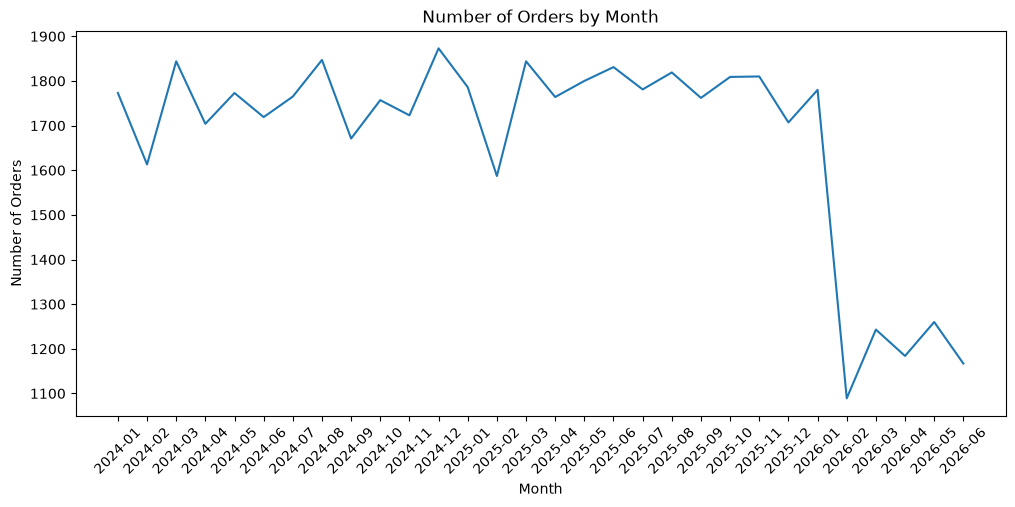

In [86]:
plt.figure(figsize=(12, 5))

plt.plot(
    orders_by_month.index.astype(str),
    orders_by_month.values
)

plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

#### Initial Observations

* The monthly distribution shows relatively stable order volumes throughout 2024 and 2025, generally remaining within a similar range.

* A lower number of orders is observed during the available months of 2026. Since the dataset does not contain a full year for 2026, this difference should not be interpreted as an annual decline in sales at this stage.

* This temporal pattern should be considered in later analyses to distinguish between actual changes in order volume and differences caused by the period covered by the dataset.

------
### Descriptive Analysis Summary

The descriptive analysis provided an initial overview of the main characteristics of the e-commerce data.

The analysis examined:

- The demographic profile and segmentation of customers.
- The distribution of order quantities, discounts, statuses, and payment methods.
- The composition and price distribution of the product catalog.
- The temporal distribution of orders.

These descriptive statistics provide a foundation for investigating relationships between customers, orders, payments, and products.

The next section focuses on these relationships and their potential business implications.

------
## 8. Relationship Analysis

* The datasets represent different business entities within the e-commerce operation. Understanding how these entities are connected is essential before performing more advanced analysis.

* This section investigates the relationships between customers, orders, products, and payments using their respective identifiers.

* The analysis focuses on identifying how records are connected and whether there are unmatched or unexpected relationships between the datasets.

### Customer–Order Relationship

The relationship between customers and orders is analyzed through the `CustomerID` field.

This analysis verifies whether orders are associated with existing customers and examines the distribution of orders across the customer base.

In [87]:
orders["CustomerID"].isin(customers["CustomerID"]).value_counts()

CustomerID
True     50090
False       30
Name: count, dtype: int64

In [88]:
customers_with_orders = (
    customers["CustomerID"]
    .isin(orders["CustomerID"])
    .sum()
)

customers_with_orders

np.int64(9939)

In [89]:
orders_per_customer = orders["CustomerID"].value_counts()

orders_per_customer.describe()

count    9940.000000
mean        5.042254
std         2.214529
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        30.000000
Name: count, dtype: float64

#### Initial Observations

* The `CustomerID` relationship indicates how customer records are connected to transactional data in the `Orders` dataset.

* The analysis confirms whether orders are associated with existing customers and shows that the relationship between customers and orders is not one-to-one, as customers can place multiple orders.

* The distribution of orders per customer provides an initial view of purchasing frequency across the customer base. This relationship will be useful for later analyses involving customer behavior, segmentation, and revenue.

-----

### Order–Product Relationship

The relationship between orders and products is analyzed through the `ProductID` field.

This analysis verifies whether the products referenced in orders exist in the product catalog and examines how orders are distributed across available products.

In [90]:
orders["ProductID"].isin(products["ProductID"]).value_counts()

ProductID
True    50120
Name: count, dtype: int64

In [91]:
orders_per_product = orders["ProductID"].value_counts()

orders_per_product.describe()

count      20.000000
mean     2506.000000
std      1387.514855
min       670.000000
25%      1663.000000
50%      2178.000000
75%      3080.500000
max      5520.000000
Name: count, dtype: float64

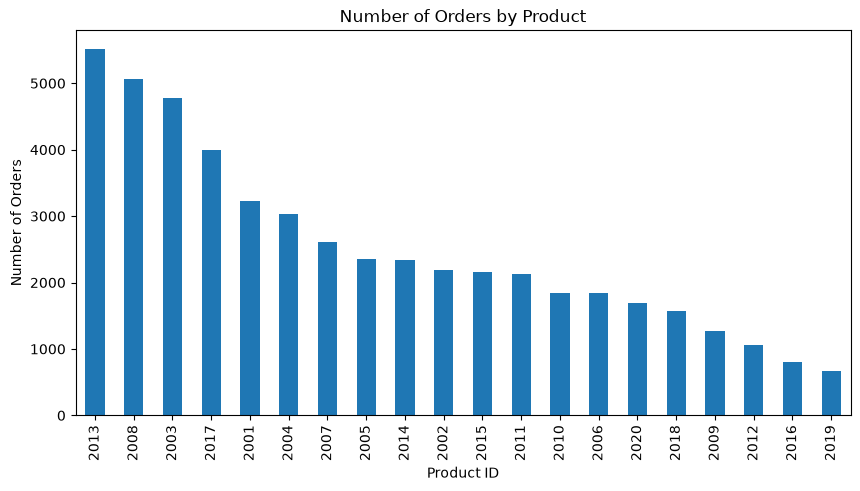

In [92]:
orders_per_product.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Number of Orders by Product")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")

plt.show()

#### Initial Observations

* The `ProductID` relationship connects transactional records to the available product catalog.

* The validation helps determine whether all products referenced in orders are present in the `Products` dataset.

* The distribution of orders across products also indicates differences in product demand, which can be explored further when analyzing sales performance, product categories, and revenue.

-----
### Order–Payment Relationship

The relationship between orders and payments is analyzed through the `OrderID` field.

This analysis verifies whether payment records can be associated with orders and investigates the consistency between the two datasets.

In [93]:
payments["OrderID"].isin(orders["OrderID"]).value_counts()

OrderID
True    50000
Name: count, dtype: int64

In [94]:
orders["OrderID"].isin(payments["OrderID"]).value_counts()

OrderID
True    50120
Name: count, dtype: int64

#### Initial Observations

* The `OrderID` field provides the connection between orders and payment records.

* The relationship analysis should be interpreted together with the duplicate records previously identified in the `Orders` dataset. The difference in record counts between the two datasets is partially explained by the duplicate order records.

* The payment data will therefore require further validation during the data processing stage before being used for financial calculations or revenue analysis.

----

### Relationship Analysis Summary

The relationship analysis established the main connections between the datasets:

- `Customers` and `Orders` are connected through `CustomerID`.
- `Orders` and `Products` are connected through `ProductID`.
- `Orders` and `Payments` are connected through `OrderID`.

These relationships show how customer, transactional, product, and payment information can be combined for further analysis.

The analysis also identified the importance of addressing duplicate records in `Orders` before performing calculations that depend on transaction-level data.

With the structure, quality, descriptive characteristics, and relationships between the datasets now understood, the next step is to consolidate the main findings before moving to data cleaning and transformation.

## 9. Initial Findings

### Data Quality

- Missing values were identified in `Customers`, `Orders`, and `Payments`, although their overall proportion is relatively low.
- `Orders` contains 120 complete duplicate records.
- No apparent invalid values were identified in `Age`, `Quantity`, `Discount`, or `UnitPrice`.
- Date variables contain missing values but no additional apparent date inconsistencies were identified.

### Relationships

- `Customers` and `Orders` are connected through `CustomerID`, with customers potentially associated with multiple orders.
- `Orders` and `Products` are connected through `ProductID`, allowing transactional data to be analyzed alongside product information.
- `Orders` and `Payments` are connected through `OrderID`.
- The difference between the number of records in `Orders` and `Payments` is related to the duplicate records identified in `Orders`.

### Potential Issues

- Missing values may affect analyses involving customer attributes, transaction dates, quantities, discounts, and payment methods.
- Duplicate order records may lead to duplicated transactions and inaccurate aggregated results if not addressed.
- Date variables are currently stored as strings and require conversion before time-based analysis.
- Relationships between datasets should be validated after cleaning to ensure consistent and reliable joins.

### Next Steps

- Remove or appropriately handle duplicate records.
- Evaluate and define strategies for handling missing values based on their business relevance.
- Convert date variables to appropriate datetime formats.
- Validate identifiers and relationships after data cleaning.
- Prepare processed datasets for exploratory and business-oriented analysis.

The next step of the project will focus on defining and implementing data cleaning strategies based on the issues identified during the data understanding stage.